# Model Interpretation: Feature Importance Analysis
**Project:** Credit Risk Decision Engine  
**Objective:** Extract and visualize the coefficients from the optimized Logistic Regression pipeline (v5.0) to identify the key financial and demographic drivers of credit default.

## 1. Environment Setup & Data Ingestion
Appending the project root to the system path to allow for modular imports from the `scripts` directory.

In [1]:
import os 
import sys
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

# Ensure scripts folder is accessible for modular pipeline imports
sys.path.append(os.path.abspath(os.path.join('..')))
from scripts.modeling_engine import train_and_evaluate, predict_risk

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# --- PATH SETUP --- 
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, os.pardir))
data_dir = os.path.join(project_root, "data")

data_path = os.path.join(data_dir, 'cleaned_german_credit.csv')
df = pd.read_csv(data_path)

## Model Training & Pipeline Execution
We initialize the **v5.0 Optimized Pipeline**, which integrates automated scaling and Logistic Regression with balanced class weights. This modular approach ensures that preprocessing transformations are consistent across both training and inference.

In [2]:
# Execute the modular modeling pipeline
# Returns:
# - model: The fitted Pipeline object (Scaler + Estimator)
# - training_cols: The exact feature set used for alignment
# - metrics: A dictionary containing Accuracy, Recall, F1, and the Confusion Matrix
model, training_cols, metrics = train_and_evaluate(df)

# Print high-level results to verify successful execution
print(f"Model Training Complete.")
print(f"Recall (High Risk): {metrics['recall']:.2f}")

Model Training Complete.
Recall (High Risk): 0.82


In [4]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## Model Evaluation: Confusion Matrix
Visualizing the performance of the **v5.0 Optimized Engine**. We use a heatmap to verify the model's ability to distinguish between "Low Risk" and "High Risk" applicants, with a specific focus on minimizing False Negatives.

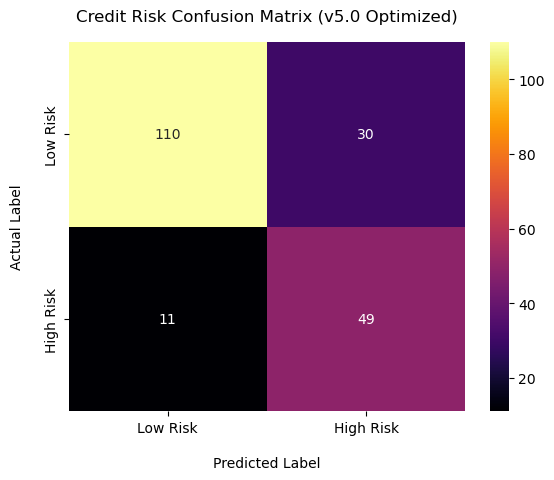

In [3]:
# Define labels for the matrix axes
risk_labels = ['Low Risk', 'High Risk']

# Create a heatmap of the confusion matrix for intuitive performance review
sns.heatmap(
    metrics['conf_matrix'], 
    annot=True, 
    fmt='d', 
    cmap='inferno',
    xticklabels=risk_labels, 
    yticklabels=risk_labels
)

# Labeling the axes to represent classification outcomes
plt.xlabel('Predicted Label', labelpad=15)
plt.ylabel('Actual Label', labelpad=15)
plt.title('Credit Risk Confusion Matrix (v5.0 Optimized)', pad=15)

# Robust pathing for the assets folder
save_path = os.path.join(project_root, 'assets', 'confusion_matrix_v.5.0.jpg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

## Feature Extraction and Coefficient Mapping
This section isolates the trained Logistic Regression estimator from the scikit-learn pipeline to analyze its internal weights. By mapping these coefficients back to their respective feature names, we transform raw model parameters into interpretable insights. This process is critical for understanding the mathematical drivers behind the risk scores and ensures that the model's decision-making process is transparent and alignable with banking domain expertise.

In [5]:
# --- Model Extraction & Coefficient Mapping ---

# Extract the fitted estimator from the Pipeline object
lr_model = model.named_steps['model']
coefficients = lr_model.coef_[0]
features = model.feature_names_in_

# Map coefficients to feature names for visualization
dict = {'var': features, 'coef': coefficients}
var_coeff_df = pd.DataFrame(dict).sort_values(by='coef').reset_index(drop=True)
#var_coeff_df = var_coeff_df[var_coeff_df['coef'] != 0]
print(var_coeff_df)

                                                  var      coef
0                          checking_status_no account -0.553945
1   credit_history_critical account/other credits ... -0.468921
2                                  purpose_car (used) -0.238989
3                   savings_status_unknown/no savings -0.222394
4                               marital_status_single -0.206861
5      credit_history_existing credits paid back duly -0.196826
6                           savings_status_> 1,000 DM -0.195899
7                                 guarantors_gurantor -0.192554
8                     employment_duration_4 - 7 years -0.156147
9                                         housing_own -0.111851
10                                    guarantors_none -0.103771
11        credit_history_delay paying off in the past -0.090377
12                          checking_status_>= 200 DM -0.075975
13                                      purpose_other -0.075182
14                           purpose_rad

## Statistical Interpretation: Feature Importance
In a Logistic Regression model, the coefficients represent the **Log-Odds** of the target variable (Credit Risk). 

* **Positive Coefficients:** Indicate that as the feature value increases, the probability of the applicant being "High Risk" also increases.
* **Negative Coefficients:** Represent features that have a "protective" effect, lowering the predicted probability of default.
* **Magnitude:** The further the bar extends from the zero-line, the stronger that specific feature's influence is on the model's final decision.

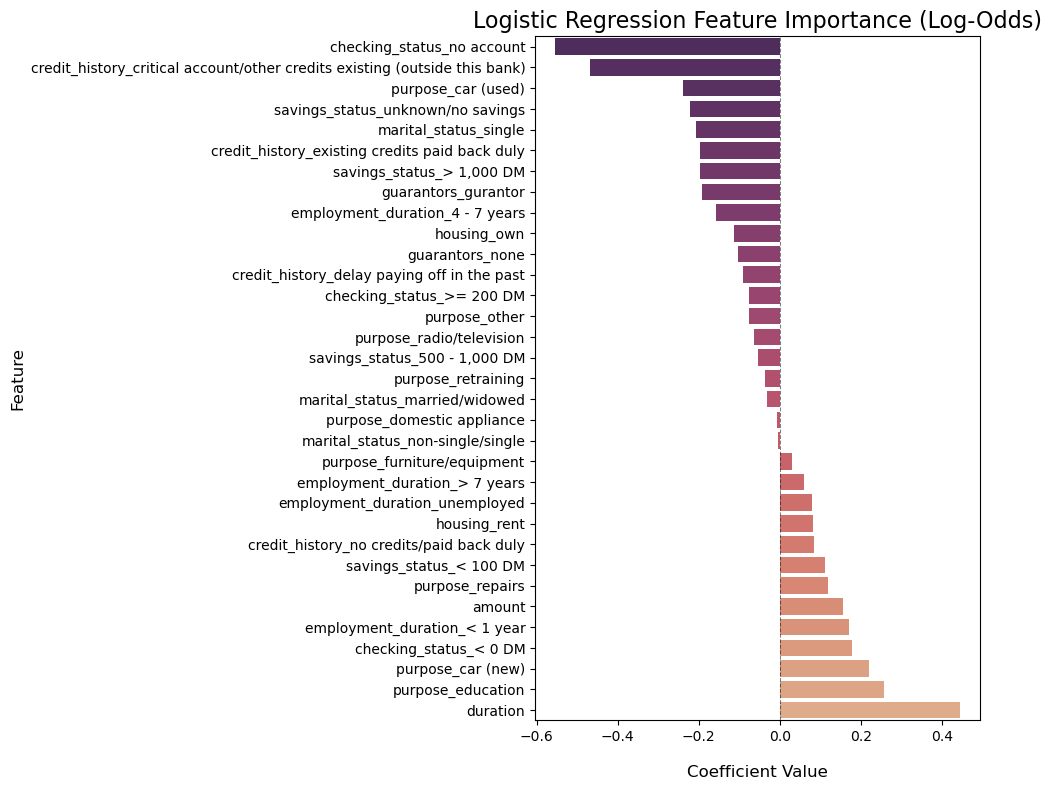

In [8]:
# --- Visualization ---
fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(x='coef', 
            y='var', 
            data=var_coeff_df, 
            palette='flare_r',
            hue='var',
           legend=False);
plt.axvline(0, color='black', linestyle='--', linewidth=0.75, alpha=0.5)

plt.title('Logistic Regression Feature Importance (Log-Odds)', size=16)
plt.xlabel('Coefficient Value', labelpad=15, size=12)
plt.ylabel('Feature', size=12)
plt.tight_layout()

# Robust pathing for the assets folder
save_path = os.path.join(project_root, 'assets', 'logistic_regression_feature_importance.png')
plt.savefig(save_path, dpi=300)

# Interpretation of Results
- **Positive Coefficients (Increase Risk):** Features like `duration` and `checking_status` have the highest positive impact on the model, indicating they are strong predictors of default.
- **Negative Coefficients (Decrease Risk):** Variables with negative values represent "protective" factors that lower the probability of a "High Risk" verdict.
- **Zero Coefficients:** Any features with a coefficient of 0 were neutralized by the **L1 (Lasso) Regularization**, effectively performing automated feature selection.